## Extended Analysis on Model Performance and Data Embeddings & Labels ##

In [3]:
import os
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from PIL import Image
from sklearn.manifold import TSNE
from torchvision import transforms
from facenet_pytorch import InceptionResnetV1
from model import Embeddinghead
from dataset import DroneFaceDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
backbone = InceptionResnetV1(pretrained='vggface2').to(device)
head = Embeddinghead(input_dim=512, Embedding_dim=256).to(device)
ckpt = torch.load('checkpoints/best_drone_model.pth', map_location=device)
backbone.load_state_dict(ckpt['backbone'])
head.load_state_dict(ckpt['head'])
backbone.eval(); head.eval()

os.makedirs('results/analysis', exist_ok=True)
print('Setup complete.')

/home/shamma.yaqoob/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.



## t-SNE Embedding Visualisation
Shows how identities cluster in 256-d embedding space after two-phase training.

In [ ]:
#Loading the raw saved embeddings for training and validation
train_embeddings = np.load('results/embeddings/cache_train_embeddings.npy')
validation_embeddings = np.load('results/embeddings/cache_validation_embeddings.npy')
train_labels = np.load('results/embeddings/cache_train_labels.npy')
validation_labels = np.load('results/embeddings/cache_validation_labels.npy')

# Remaping validation identity label 0 → 8 (identity I, distinct from train identity A)
validation_labels_remapped = validation_labels + 8
baseline_embeddings = np.concatenate([train_embeddings, validation_embeddings], axis=0)
baseline_labels = np.concatenate([train_labels, validation_labels_remapped], axis=0)

# Loading saved embeddings after two-phase training
embeddings = np.load('results/embeddings/two_phase_droneface.npy')
labels = np.load('results/embeddings/two_phase_droneface_labels.npy')

print(f'Embeddings: {embeddings.shape}  |  Unique identities: {len(set(labels))}')

Embeddings: (1437, 256)  |  Unique identities: 11


In [5]:
from sklearn import __version__ as sk_version
#T_SNE method: 
def tsne(embs):
    tsne_kwargs = {
        "n_components":2,
        "perplexity": min(30, len(embs) // 4),   # auto-adjust for small datasets
        'random_state':42,
        'verbose':1
    }

    if tuple(int(x) for x in sk_version.split(".")[:2]) >= (1,5):
        tsne_kwargs["max_iter"] = 1000
    else: 
        tsne_kwargs["n_iter"] = 1000
    return TSNE(**tsne_kwargs).fit_transform(embs)

baseline_tsne = tsne(baseline_embeddings)
twophase_tsne = tsne(embeddings)
print('t-SNE done.')

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1175 samples in 0.001s...
[t-SNE] Computed neighbors for 1175 samples in 0.231s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1175
[t-SNE] Computed conditional probabilities for sample 1175 / 1175
[t-SNE] Mean sigma: 0.279366
[t-SNE] KL divergence after 250 iterations with early exaggeration: 59.266499
[t-SNE] KL divergence after 1000 iterations: 0.553398
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1437 samples in 0.000s...
[t-SNE] Computed neighbors for 1437 samples in 0.024s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1437
[t-SNE] Computed conditional probabilities for sample 1437 / 1437
[t-SNE] Mean sigma: 0.176719
[t-SNE] KL divergence after 250 iterations with early exaggeration: 63.721252
[t-SNE] KL divergence after 1000 iterations: 0.664689
t-SNE done.


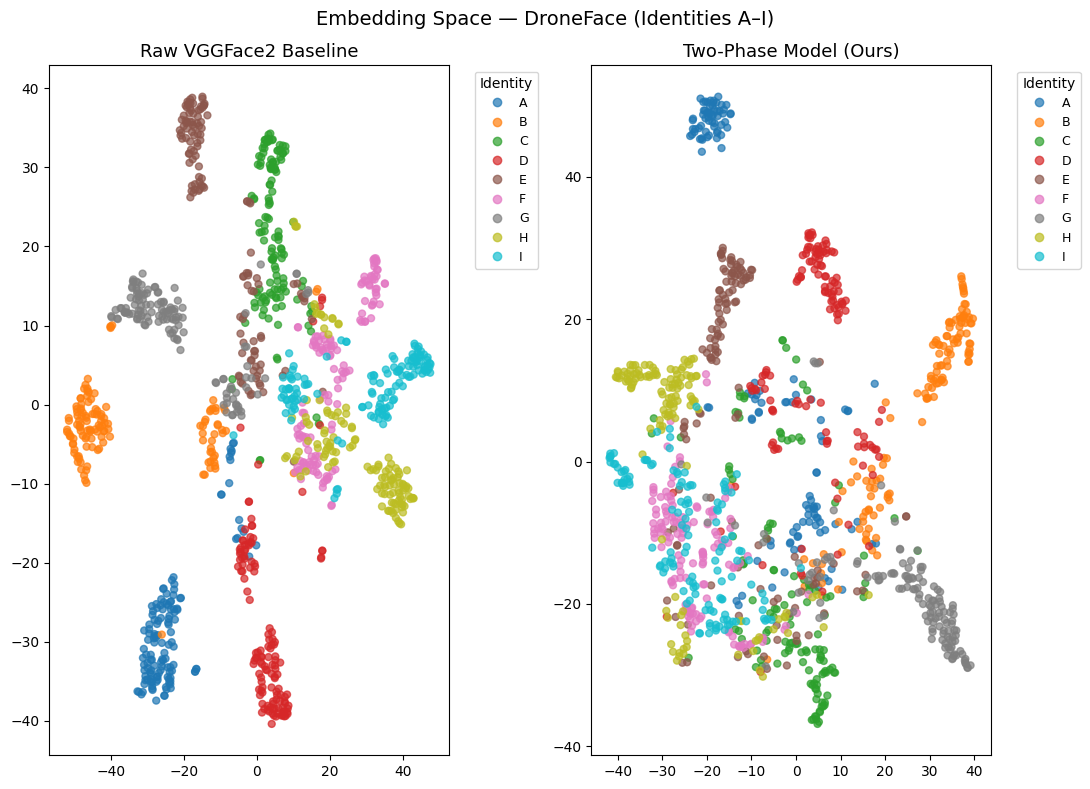

In [17]:
# Plot side-by-side t-SNE visualizations for baseline vs two-phase model
LABEL_MAP = {'A':0,'B':1,'C':2,'D':3,'E':4,'F':5,'G':6,'H':7,'I':8}

# convert two-phase string labels to int, drop J/K
mask = np.array([l in LABEL_MAP for l in labels])
tp_proj = twophase_tsne[mask]
tp_labels = np.array([LABEL_MAP[l] for l in labels[mask]])

cmap = plt.colormaps['tab10']
fig, axes = plt.subplots(1, 2, figsize=(11, 8))

for ax, proj, lbl, title in zip(
    axes,
    [baseline_tsne, tp_proj],
    [baseline_label, tp_labels],
    ['Raw VGGFace2 Baseline', 'Two-Phase Model (Ours)']
):
    scatter = ax.scatter(proj[:, 0], proj[:, 1], c=lbl, cmap='tab10', s=25, alpha=0.7)
    ax.set_title(title, fontsize=13)
    handles, _ = scatter.legend_elements()
    ax.legend(handles, ['A','B','C','D','E','F','G','H','I'], 
          title='Identity', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.suptitle('Embedding Space — DroneFace (Identities A–I)', fontsize=14)
plt.tight_layout()
plt.savefig('results/analysis/tsne_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

## Confusion Matrix and ROC Data Visualization

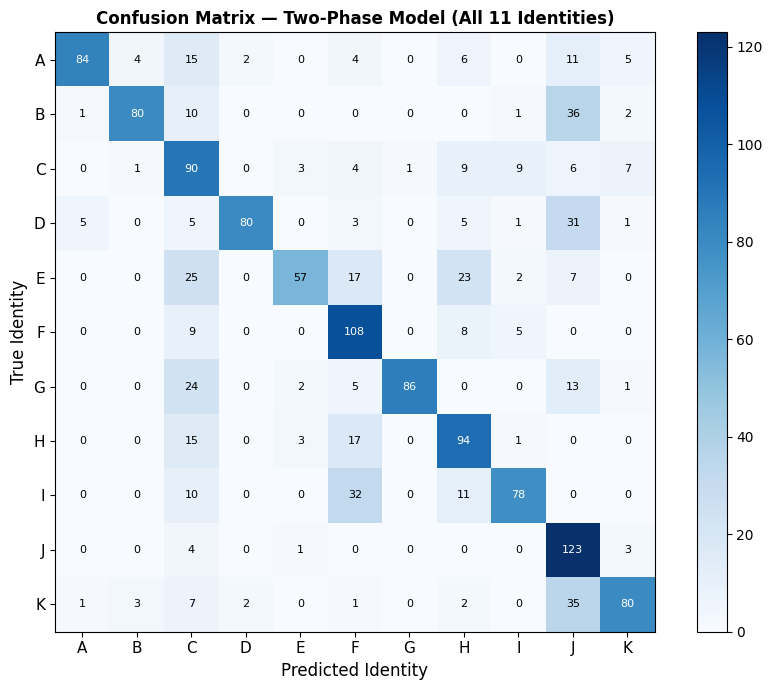

Confusion matrix saved.
Micro-AUC: 0.7443


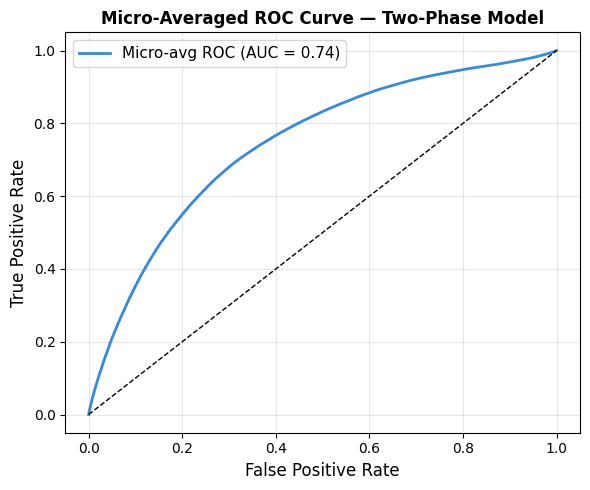

ROC curve saved. AUC = 0.7443


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Loading the confusion matrix and ROC data
confusion_matrix = np.load('results/confusion_matrix.npy')
roc_data = np.load('results/roc_data.npy', allow_pickle=True)
id_names = ['A','B','C','D','E','F','G','H','I','J','K']

# Plotting the confusion matrix
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(confusion_matrix, cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(11))
ax.set_yticks(range(11))
ax.set_xticklabels(id_names, fontsize=11)
ax.set_yticklabels(id_names, fontsize=11)
ax.set_xlabel('Predicted Identity', fontsize=12)
ax.set_ylabel('True Identity', fontsize=12)
ax.set_title('Confusion Matrix - Two-Phase Model (All 11 Identities)',
             fontsize=12, fontweight='bold')

for i in range(11):
    for j in range(11):
        validation = confusion_matrix[i, j]
        color = 'white' if validation > confusion_matrix.max() / 2 else 'black'
        ax.text(j, i, str(validation), ha='center', va='center',
                fontsize=8, color=color)

plt.tight_layout()
plt.savefig('results/analysis/confusion_matrix_full.png', dpi=200, bbox_inches='tight')
plt.show()
print('Confusion matrix saved.')

# Plotting the ROC curve and calculating AUC
y_true  = roc_data[0]
y_score = roc_data[1]

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)
print(f'Micro-AUC: {roc_auc:.4f}')

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#378ADD', lw=2,
        label=f'Micro-avg ROC (AUC = {roc_auc:.2f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Micro-Averaged ROC Curve — Two-Phase Model',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/analysis/roc_curve_full.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'ROC curve saved. AUC = {roc_auc:.4f}')

## Per-Identity Accuracy and Error Rate & Worst Failure Cases ##


Identity  Accuracy (%)  Error Rate (%)  Total Samples
       A         64.12           35.88            131
       B         61.54           38.46            130
       C         69.23           30.77            130
       D         61.07           38.93            131
       E         43.51           56.49            131
       F         83.08           16.92            130
       G         65.65           34.35            131
       H         72.31           27.69            130
       I         59.54           40.46            131
       J         93.89            6.11            131
       K         61.07           38.93            131


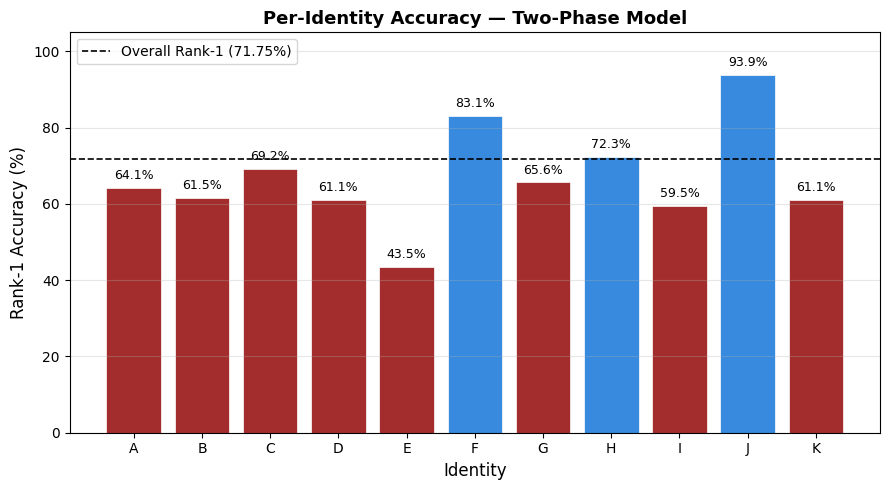


Top 10 worst failure cases:
True Predicted  Count  Error Rate (%)
   B         J     36           27.69
   K         J     35           26.72
   I         F     32           24.43
   D         J     31           23.66
   E         C     25           19.08
   G         C     24           18.32
   E         H     23           17.56
   H         F     17           13.08
   E         F     17           12.98
   A         C     15           11.45


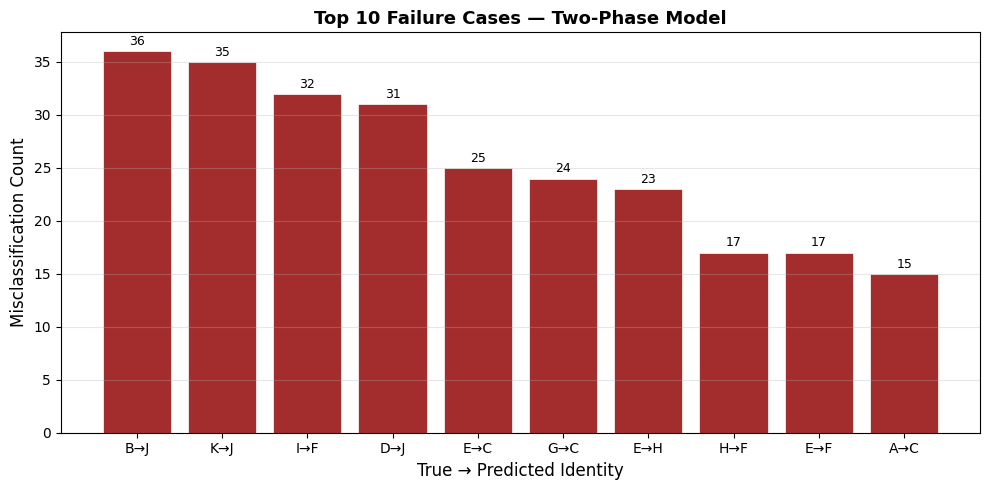

Saved both figures.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

cm = np.load('results/confusion_matrix.npy')
id_names = ['A','B','C','D','E','F','G','H','I','J','K']

# Calculating per-identity accuracy and error rate
per_id_acc = cm.diagonal() / cm.sum(axis=1) * 100
per_id_err = 100 - per_id_acc

df = pd.DataFrame({
    'Identity': id_names,
    'Accuracy (%)': per_id_acc.round(2),
    'Error Rate (%)': per_id_err.round(2),
    'Total Samples': cm.sum(axis=1)
})
print(df.to_string(index=False))

# Plotting per-identity accuracy
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#A32D2D' if a < 70 else '#378ADD' for a in per_id_acc]
bars = ax.bar(id_names, per_id_acc, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(y=71.75, color='black', linestyle='--', linewidth=1.2, label='Overall Rank-1 (71.75%)')
ax.set_xlabel('Identity', fontsize=12)
ax.set_ylabel('Rank-1 Accuracy (%)', fontsize=12)
ax.set_title('Per-Identity Accuracy — Two-Phase Model', fontsize=13, fontweight='bold')
ax.set_ylim(0, 105)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, per_id_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('results/analysis/per_identity_accuracy.png', dpi=200, bbox_inches='tight')
plt.show()

# Identifying worst failure cases from the confusion matrix
# Find top confused pairs (off-diagonal)
confusion_pairs = []
for i in range(len(id_names)):
    for j in range(len(id_names)):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append({
                'True': id_names[i],
                'Predicted': id_names[j],
                'Count': cm[i, j],
                'Error Rate (%)': round(cm[i, j] / cm[i].sum() * 100, 2)
            })

failures_df = pd.DataFrame(confusion_pairs).sort_values('Count', ascending=False)
print('\nTop 10 worst failure cases:')
print(failures_df.head(10).to_string(index=False))

# Plot top 10 confusion pairs
top10 = failures_df.head(10)
labels = [f"{r['True']}→{r['Predicted']}" for _, r in top10.iterrows()]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(labels, top10['Count'], color='#A32D2D', edgecolor='white', linewidth=0.5)
ax.set_xlabel('True → Predicted Identity', fontsize=12)
ax.set_ylabel('Misclassification Count', fontsize=12)
ax.set_title('Top 10 Failure Cases — Two-Phase Model', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, count in zip(ax.patches, top10['Count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(count)), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('results/analysis/worst_failure_cases.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved both figures.')